# 前言
**价量相关性的平均数因子**：该因子依托成交量相关信息，对传统反转因子在个股价格涨跌判断上进行了修正。价格涨跌引发的反转并非仅由价格自身决定，还需结合成交量信息加以验证。若存在成交量的配合确认，月度行情的反转效应会更为显著；若缺乏成交量的确认，月度行情则更易表现出动量特征。

**价量相关性的波动性因子**：该因子从价量形态稳定性维度对反转因子进行优化。无论个股历史价格涨跌情况如何，只要单日价量关系保持相对稳定的形态，次月股价上涨的概率更高；而价量关系在不同形态间频繁转换的个股，次月股价下跌的可能性更大。

**价量相关性的趋势因子**：个股价量相关性的变动趋势中蕴含着具备有效性的选股信号。回测结果表明，价量相关系数随时间逐步降低的个股，次月获取收益的水平往往更高。

In [23]:
# 标准库导入
import sys
import functools
import warnings
from typing import List, Tuple, Dict, Callable, Union

# 第三方数据与计算库
import numpy as np
import pandas as pd
import scipy
from scipy.stats import pearsonr

import statsmodels.api as sm
import empyrical as ep
import alphalens as al
import alphalens.performance as perf

# 可视化相关库
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns

# 进度条工具
from tqdm import tqdm_notebook

# 聚宽平台 API
from jqdata import *
from jqfactor import calc_factors, Factor

# 项目路径配置
sys.path.append("../..")

# 项目内部工具模块
from source.trade_calendar_tool import Tdaysoffset, get_trade_period
from source.stock_universe_filter import Filter_Stocks
from source.backtest_evaluator import (
    get_performance_table,
    get_information_table,
    calc_mono_score
)

# Matplotlib 绘图全局设置
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

# 价量相关性因子的构建
通过研究探索，本文确定了一套提取有效信息的构建方法，研究样本选取全部A股标的，并剔除ST个股、停牌个股以及上市交易时长不足60个交易日的次新股，回测区间设定为2014/01/01-2021/11/30，具体构建步骤如下：
1. 每月月末，对每只个股过去20个交易日的价量数据进行回溯，按日计算个股分钟收盘价与分钟成交量之间的相关系数；
2. 计算每只个股20日相关系数的均值，并进行横截面市值中性化处理，处理后结果定义为平均数因子PV_corr_avg；
3. 计算每只个股20日相关系数的标准差，同样开展市值中性化处理，处理后结果定义为波动性因子PV_corr_std；
4. 采用等权线性组合的方式整合上述两个因子的信息，先对PV_corr_avg与PV_corr_std分别进行横截面标准化处理，再将二者相加得到价量相关性综合因子PV_corr，计算公式如下：

$$PV\_corr = \frac{PV\_corr\_avg-mean(PV\_corr\_avg)}{std(PV\_corr_avg)}+\frac{PV\_corr\_std-mean(PV\_corr\_std)}{std(PV\_corr\_std)}$$

## 价量相关性因子的逻辑
### 平均数因子
首先分析平均数因子PV_corr_avg，该因子用于刻画个股过去20个交易日价量相关性的平均水平，回测结果显示，**个股价量相关系数数值越低，其未来预期收益水平往往越高**。经深入分析，该因子本质上是对传统反转因子的优化修正。如下图所示，传统反转因子认为个股月度行情具备反转特征，过去20个交易日上涨的个股次月更易下跌，应归类为空头；过去20个交易日下跌的个股次月更易上涨，应归类为多头。**而价量相关性平均数因子PV_corr_avg引入成交量维度信息，进一步细化了反转因子对个股价格形态的划分标准**。

针对价格上涨走势，可细分为放量上涨与缩量上涨两类，其中放量上涨对应的价量相关系数较高，缩量上涨对应的价量相关系数较低，PV_corr_avg因子对二者采取差异化的判断逻辑。历史走势为放量上涨的个股，如同强弩之末，后续上涨动能已充分消耗，次月更大概率出现下跌走势，该判断与传统反转因子保持一致；而历史走势为缩量上涨的个股，上涨动能仍在持续释放，前期涨幅尚未充分兑现，次月更易延续原有上涨趋势，该判断与传统反转因子相反。

针对价格下跌走势，同样可划分为放量下跌与缩量下跌两类，其中放量下跌对应的价量相关系数较低，缩量下跌对应的价量相关系数较高，PV_corr_avg因子对两类个股同样给出不同判断。放量下跌的个股，因子判断逻辑与反转因子一致，认为次月行情更易实现反转，将其划分为多头标的；而历史以缩量下跌为主的个股，因尚未完成放量见底的过程，次月反转力度相对较弱，仍被划分为空头标的，该判断与反转因子存在差异。

综上，平均数因子PV_corr_avg对传统反转因子的修正逻辑可概括为：**价格涨跌引发的反转并非仅由价格自身决定，还需结合成交量信息加以验证，若有成交量配合确认，月度行情的反转效应会更为显著；若缺乏成交量确认，月度行情则更易呈现动量效应**。

### 波动性因子
接下来分析PV_corr_std因子，该因子用于衡量个股历史价量相关性的波动程度，回测结果表明，**因子数值越小，个股未来预期收益水平越高**。本文从四类价量关系出发，解析该因子的选股逻辑。

针对缩量上涨与放量下跌两类走势，若个股价量相关系数波动幅度较小，说明其在过去20个交易日内持续稳定呈现对应价量形态，此时因子判断逻辑与PV_corr_avg因子一致，将该类个股划分为多头标的。

而对于放量上涨与缩量下跌两类走势，PV_corr_std因子的判断逻辑与PV_corr_avg因子存在区别。若个股持续稳定呈现放量上涨形态，价量相关系数波动较小，说明其上涨动能充足且具备持续支撑，次月仍有望延续上涨走势，应划分为多头标的；若个股持续稳定呈现缩量下跌形态，因子判断逻辑与反转因子一致，认为次月行情更易实现反转并出现上涨。

总体而言，**波动性因子PV_corr_std所蕴含的选股信息同样可视为对反转因子的修正：无论个股历史价格走势为上涨或下跌，只要其单日价量关系保持稳定形态，便会被PV_corr_std因子判定为未来多头标的；若价量关系在不同形态间频繁切换，则会被划分为空头标的**。

**小结**
结合前两部分的分析结论可以归纳，价量相关性因子可视为对传统反转因子的优化与修正。

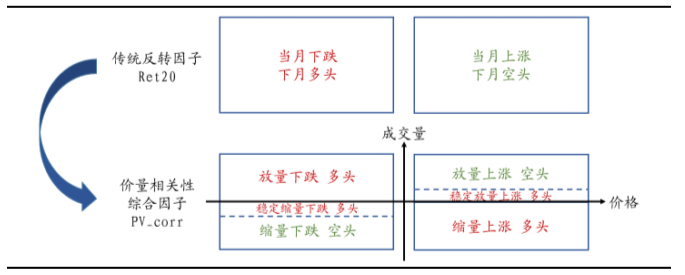

由上述分析可知，PV_corr可视为对传统反转因子的修正，价量相关性因子所包含的选股信息与传统反转因子必然存在一定重叠。为进一步提炼提纯选股信息，可执行如下操作：**先将PV_corr_avg与PV_corr_std两个子因子分别剔除反转因子的影响，再对处理后的因子分别进行横截面标准化处理，最后通过等权线性相加构建综合因子，将该新因子命名为PV_corr_deRet20。**

# 趋势因子的增量信息
基于前文的研究结论，本文进一步发现个股价量相关性的变动趋势能够提供额外的增量信息，因此本节将对该类信息展开深入挖掘，并最终构建包含价量相关性三个维度信息的综合因子。

## 价量相关性的趋势因子
本节所构建选股因子的具体计算步骤如下：
1. 每月月末，依旧回溯每只个股过去20个交易日的价量数据，按日计算个股分钟收盘价与分钟成交量的相关系数；
2. 将每只个股对应的20期相关系数𝜌𝑡对时间变量𝑡进行回归，提取回归系数𝛽，回归方程为𝜌𝑡 = 𝛽 ∗ 𝑡 + 𝜀𝑡，其中𝑡的取值为1,2,3,……,20；
3. 将全市场个股的回归系数𝛽在横截面层面剔除市值、传统价量类因子（20日反转因子、20日换手率因子、20日波动率因子）的影响，处理后所得结果定义为趋势因子PV_corr_trend。

## 最终的价量相关性因子——CPV
经实证检验，上节构建的趋势因子PV_corr_trend在剔除原有综合因子PV_corr_deRet20的影响后，依然具备一定的选股效果。因此本文将PV_corr_trend所包含的增量信息与PV_corr_deRet20进行融合，最终构建的因子命名为CPV因子（Correlation of Price and Volume），该因子整合了本报告提出的价量相关性三个维度的全部信息：

$$CPV = \frac{PV\_corr\_deRet20+mean(PV\_corr\_deRet20)}{std(PV\_corr\_deRet20)} + \frac{PV\_corr\_trend-mean(PV\_corr\_trend)}{std(PV\_corr\_trend)}$$

In [2]:
# 因子构建核心模块
# 包含股票分片、分钟数据获取、量价相关性计算、因子中性化与回归处理
def split_stock_list(max_limit: int = 500):
    """
    装饰器：对标的列表进行自动分片处理
    解决单次请求标的数量过大导致的数据获取失败问题
    """
    def wrapper_decorator(target_func: Callable):
        @functools.wraps(target_func)
        def inner_func(*args, **kwargs):
            # 从参数中提取标的列表
            if "securities" not in kwargs:
                stock_list = args[0]
                remaining_args = args[1:]
            else:
                stock_list = kwargs["securities"]
                del kwargs["securities"]
                remaining_args = args

            # 统一转换为列表格式
            if isinstance(stock_list, str):
                stock_list = [stock_list]

            total_count = len(stock_list)
            # 超过限制则分批执行并合并结果
            if total_count > max_limit:
                result_frames = []
                for idx in range(0, total_count, max_limit):
                    batch = stock_list[idx:idx + max_limit]
                    batch_result = target_func(batch, *remaining_args, **kwargs)
                    result_frames.append(batch_result)
                return pd.concat(result_frames)
            else:
                return target_func(stock_list, *remaining_args, **kwargs)

        return inner_func

    return wrapper_decorator


@split_stock_list()
def fetch_minute_data(
    securities: Union[str, List],
    end_date: str,
    window_days: int
) -> pd.DataFrame:
    """
    获取股票日内分钟级行情数据
    固定获取每天240根1分钟K线
    """
    return get_price(
        securities,
        end_date=f"{end_date} 15:00:00",
        count=240 * window_days,
        frequency="1m",
        fields=["close", "volume"],
        panel=False
    )


def compute_pearson_correlation(price_data: pd.DataFrame) -> pd.Series:
    """
    按交易日分组，计算收盘价与成交量的皮尔逊相关系数
    """
    date_group = price_data.index.normalize()
    return price_data.groupby(date_group).apply(
        lambda x: pearsonr(x["close"], x["volume"])[0]
    )


def standardize_z_score(series: pd.Series) -> pd.Series:
    """
    对序列执行Z-score标准化处理
    用于因子归一化
    """
    return (series - series.mean()) / series.std()


def run_linear_regression(
    x_series: pd.Series,
    y_series: pd.Series,
    output: str = "resid"
) -> pd.Series:
    """
    执行OLS线性回归，返回指定结果（残差/系数等）
    自动处理缺失值
    """
    model = sm.OLS(
        y_series.fillna(0),
        sm.add_constant(np.nan_to_num(x_series))
    )
    regression_result = model.fit()
    return getattr(regression_result, output)


def neutralize_factor(
    base_factor: pd.Series,
    control_factor: Union[pd.Series, pd.DataFrame],
    apply_standardize: bool = True
) -> pd.Series:
    """
    通过回归剔除控制因子的影响，实现因子中性化
    支持标准化输出
    """
    residual_series = run_linear_regression(control_factor, base_factor, "resid")

    if apply_standardize:
        final_series = standardize_z_score(residual_series)
    else:
        final_series = residual_series

    return final_series


@split_stock_list()
def compute_pv_correlation(
    securities: Union[list, str],
    end_date: str,
    window: int,
    market_value: pd.Series
) -> pd.DataFrame:
    """
    计算量价相关性系列因子
    包含均值、波动率、趋势、市值中性化处理
    """
    # 获取分钟级行情数据
    price_detail = fetch_minute_data(securities, end_date=end_date, count=window)

    # 计算每日量价相关系数
    pv_corr_matrix = (
        price_detail.set_index("time")
        .groupby("code")
        .apply(compute_pearson_correlation)
        .T
    )

    # 计算趋势项（回归系数）
    def calc_beta(series):
        return run_linear_regression(np.arange(1, len(series)+1), series, "params")[1]

    pv_trend_beta = pv_corr_matrix.apply(calc_beta)

    # 基础统计量因子
    pv_mean = pv_corr_matrix.mean()
    pv_std = pv_corr_matrix.std()

    # 市值中性化
    mv_standardized = standardize_z_score(market_value.loc[securities])
    pv_mean_neu = neutralize_factor(pv_mean, mv_standardized, False)
    pv_std_neu = neutralize_factor(pv_std, mv_standardized, False)
    pv_trend_neu = neutralize_factor(pv_trend_beta, mv_standardized, False)

    # 合成综合因子
    pv_combined = standardize_z_score(pv_mean_neu) + standardize_z_score(pv_std_neu)

    # 组装输出
    output_frame = pd.concat([pv_mean_neu, pv_std_neu, pv_combined, pv_trend_neu], axis=1)
    output_frame.columns = ["pv_corr_avg", "pv_corr_std", "pv_corr", "pv_corr_trend"]

    return output_frame


class PVCorrFactor(Factor):
    """
    量价相关性因子（PV Correlation）
    聚宽Factor规范实现
    """
    warnings.filterwarnings("ignore")
    name = "PV_corr"
    max_window = 20
    dependencies = ["market_cap", "ROC20", "VOL20", "close"]

    def calc(self, data: Dict) -> pd.Series:
        code_list = data["market_cap"].columns.tolist()
        trade_date = data["market_cap"].index[-1].strftime("%Y-%m-%d")
        latest_mv = data["market_cap"].iloc[-1]

        # 构建控制因子集合
        vol_20d = data["close"].pct_change().std()
        roc_20d = data["ROC20"].iloc[-1]
        volume_ratio = data["VOL20"].iloc[-1]
        control_features = pd.concat([roc_20d, volume_ratio, vol_20d], axis=1)
        control_features = control_features.apply(standardize_z_score)

        # 计算基础量价因子
        factor_result = compute_pv_correlation(
            securities=code_list,
            end_date=trade_date,
            window=self.max_window,
            market_cap=latest_mv
        )

        # 剔除共同因子影响
        pv_avg_neu = neutralize_factor(factor_result["pv_corr_avg"], control_features, True)
        pv_std_neu = neutralize_factor(factor_result["pv_corr_std"], control_features, True)

        # 合成进阶因子
        factor_result["pv_corr_deret20"] = pv_avg_neu + pv_std_neu
        factor_result["pv_corr_trend"] = neutralize_factor(
            factor_result["pv_corr_trend"], control_features, False
        )
        factor_result["CPV"] = standardize_z_score(factor_result["pv_corr_deret20"]) + \
                               standardize_z_score(factor_result["pv_corr_trend"])

        # 保存中间结果
        self.market_cap = latest_mv
        self.other_factor = control_features
        self.pv_corr_factor = factor_result


# 因子获取与回测工具模块
def generate_factor_data(pool_code: str, trade_dates) -> pd.DataFrame:
    """
    按交易日循环生成因子数据
    自动过滤停牌、ST、次新股
    """
    for current_dt in tqdm_notebook(trade_dates, desc="因子计算"):
        stock_filter = Filter_Stocks(pool_code, current_dt)
        stock_filter.filter_paused(21, 20)
        stock_filter.filter_st()
        stock_filter.filter_ipodate(60)

        pv_factor = PVCorrFactor()
        target_codes = stock_filter.securities
        calc_factors(target_codes, [pv_factor], start_date=current_dt, end_date=current_dt)
        yield pv_factor.pv_corr_factor


def fetch_period_close_price(security: Union[List, str], periods: List) -> pd.DataFrame:
    """
    按周期获取收盘价数据
    """
    for trade_dt in tqdm_notebook(periods, desc="获取收盘价"):
        yield get_price(
            security,
            end_date=trade_dt,
            count=1,
            fields="close",
            fq="post",
            panel=False
        )


def build_price_table(factor_frame: pd.DataFrame, last_date: str = None) -> pd.DataFrame:
    """
    根据因子索引构建价格矩阵
    用于Alphalens分析
    """
    if last_date is not None:
        date_list = factor_frame.index.levels[0].tolist() + [pd.to_datetime(last_date)]
    else:
        date_list = factor_frame.index.levels[0]

    stock_list = factor_frame.index.levels[1].tolist()
    price_data_list = list(fetch_period_close_price(stock_list, date_list))
    combined_price = pd.concat(price_data_list)

    pivot_price = pd.pivot_table(
        combined_price,
        index="time",
        columns="code",
        values="close"
    )
    return pivot_price


class FactorReturnAnalyzer(object):
    """
    因子收益分析类
    基于Alphalens计算分组收益与多空收益
    """
    def __init__(
        self,
        factor_data: pd.DataFrame,
        target_col: str,
        max_data_loss: float
    ) -> None:
        self.factor_data = factor_data
        self.target_col = target_col
        self.factor_name = target_col
        self.max_loss = max_data_loss

    def calculate_returns(
        self,
        price_table: pd.DataFrame,
        periods: Tuple = (1,),
        group_q: int = 5
    ) -> pd.DataFrame:
        """
        清洗因子并计算未来收益
        """
        factor_series = self.factor_data[self.target_col]
        clean_factor = al.utils.get_clean_factor_and_forward_returns(
            factor_series,
            price_table,
            periods=periods,
            quantiles=group_q,
            max_loss=self.max_loss
        )

        self.clean_factor = clean_factor

        # 分组日收益
        self.group_daily_ret = pd.pivot_table(
            clean_factor.reset_index(),
            index="date",
            columns="factor_quantile",
            values=1
        )

        # 分组累计收益
        self.group_cum_ret = ep.cum_returns(self.group_daily_ret)

    def calculate_long_short(self, low_q: int = 1, high_q: int = 5) -> pd.Series:
        """
        计算多空组合收益
        """
        if not hasattr(self, "group_daily_ret"):
            raise ValueError("请先调用 calculate_returns 方法")

        self.long_short_ret = self.group_daily_ret[high_q] - self.group_daily_ret[low_q]
        self.long_short_ret.name = f"{self.factor_name}_excess_return"

        self.long_short_cum = ep.cum_returns(self.long_short_ret)
        self.long_short_cum.name = f"{self.factor_name}_cumulative_excess"

In [3]:
# ================================
# 因子数据生成、整合与持久化存储
# ================================

# 获取指定范围内的月度交易日序列
trade_date_list = get_trade_period('2014-01-01', '2021-10-31', 'ME')

# 批量生成全A市场的CPV因子数据
factor_result_list = list(generate_factor_data('A', trade_date_list))

# 构建多层索引因子数据表（date + asset）
factor_combined = pd.concat(
    {date_val: data_frame for date_val, data_frame in zip(trade_date_list, factor_result_list)},
    names=['date', 'asset']
)

# 将最终因子数据保存至本地文件
factor_combined.to_csv('cpv_factor_result.csv')

In [4]:
# ================================
# 因子数据读取与价格数据获取
# ================================

# 从本地CSV加载已生成的因子数据，构建多层索引
factor_combined = pd.read_csv(
    'cpv_factor_result.csv',
    index_col=[0, 1],
    parse_dates=['date']
)

# 获取对应日期的价格矩阵，用于后续Alphalens分析
price_matrix = build_price_table(factor_combined, '2021-11-30')

In [5]:
# ================================
# 查看最终合成的因子数据集结构
# ================================

# 展示数据集末尾5行，用于确认索引与列格式正确
factor_combined.tail()

pv_corr_avg    ...          CPV
date       asset                       ...             
2021-10-29 688799.XSHG    -0.040364    ...    -0.588403
           688800.XSHG    -0.044931    ...    -0.217781
           688819.XSHG     0.022162    ...     1.386607
           688981.XSHG    -0.035503    ...    -1.765053
           689009.XSHG    -0.017115    ...    -0.155996

[5 rows x 6 columns]

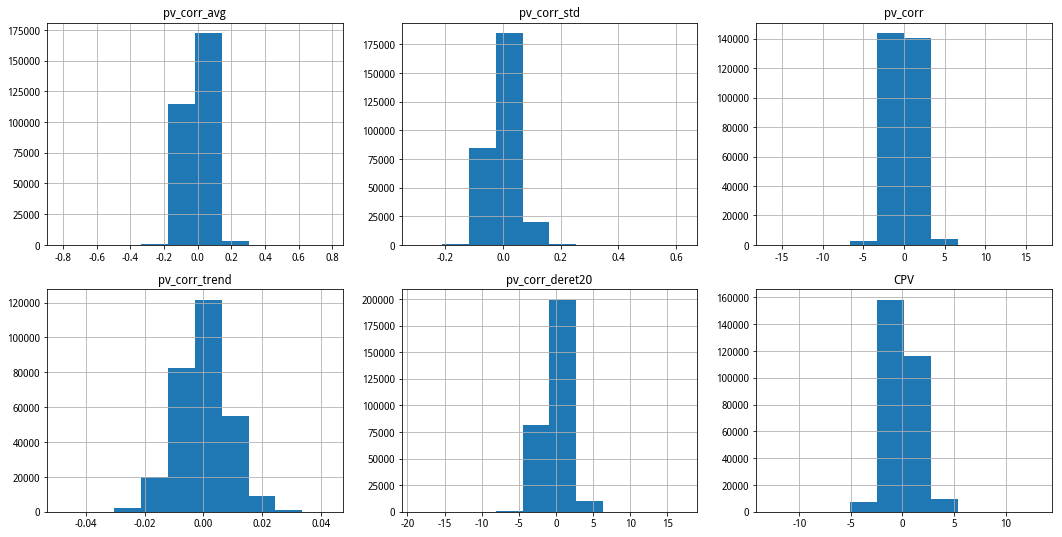

In [8]:
# ================================
# 因子分布可视化
# 展示各因子值的直方图分布
# ================================

# 创建多子图布局
fig, axis_array = plt.subplots(2, 3, figsize=(18, 9))

# 将二维子图数组展平为一维
axis_list = [item for sub_axis in axis_array for item in sub_axis]

# 循环绘制每个因子的分布直方图
for ax, (factor_name, factor_series) in zip(axis_list, factor_combined.items()):
    ax.set_title(factor_name)
    factor_series.hist(ax=ax)

In [9]:
# ================================
# 批量执行因子回测与绩效分析
# ================================

# 获取所有需要回测的因子名称
factor_name_list = factor_combined.columns.tolist()

# 用于存储每个因子的回测结果
backtest_result_dict = {}

# 遍历所有因子，逐一计算多空收益
for name_item in factor_name_list:
    # 初始化因子收益分析器
    analyzer = FactorPerformanceEvaluator(factor_combined, name_item, max_allowed_loss=0.4)
    
    # 计算分组收益
    analyzer.compute_returns(price_matrix)
    
    # 计算多空对冲收益（Q5 - Q1）
    analyzer.compute_long_short_return(low_q=1, high_q=5)
    
    # 保存结果
    backtest_result_dict[name_item] = analyzer

Dropped 0.0% entries from factor data (0.0% after in forward returns computation and 0.0% in binning phase). Set max_loss=0 to see potentially suppressed Exceptions.
Dropped 0.0% entries from factor data (0.0% after in forward returns computation and 0.0% in binning phase). Set max_loss=0 to see potentially suppressed Exceptions.
Dropped 0.0% entries from factor data (0.0% after in forward returns computation and 0.0% in binning phase). Set max_loss=0 to see potentially suppressed Exceptions.
Dropped 0.0% entries from factor data (0.0% after in forward returns computation and 0.0% in binning phase). Set max_loss=0 to see potentially suppressed Exceptions.
Dropped 0.0% entries from factor data (0.0% after in forward returns computation and 0.0% in binning phase). Set max_loss=0 to see potentially suppressed Exceptions.
Dropped 0.0% entries from factor data (0.0% after in forward returns computation and 0.0% in binning phase). Set max_loss=0 to see potentially suppressed Exceptions.


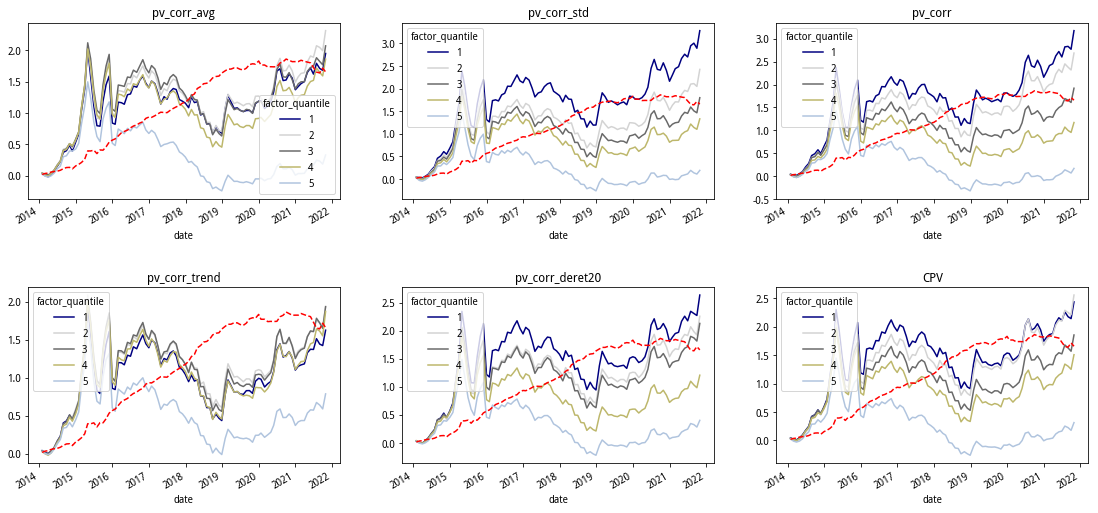

In [19]:
# ================================
# 多因子批量回测与收益分析
# 对所有因子执行分组回测 + 多空对冲计算
# ================================

# 获取全部因子的列名
all_factor_names = factor_combined.columns.tolist()

# 创建字典用于保存每个因子的分析结果
factor_analysis_results = dict()

# 遍历每一个因子，执行完整回测流程
for factor_name in all_factor_names:
    
    # 初始化因子分析类，允许最大40%数据损失
    evaluator = FactorPerformanceEvaluator(
        factor_frame=factor_combined,
        factor_col=factor_name,
        max_allowed_loss=0.4
    )
    
    # 计算因子分组收益
    evaluator.compute_returns(price_matrix=price_matrix)
    
    # 计算多空收益：高分组减去低分组（第5组 - 第1组）
    evaluator.compute_long_short_return(low_q=1, high_q=5)
    
    # 将结果存入字典
    factor_analysis_results[factor_name] = evaluator

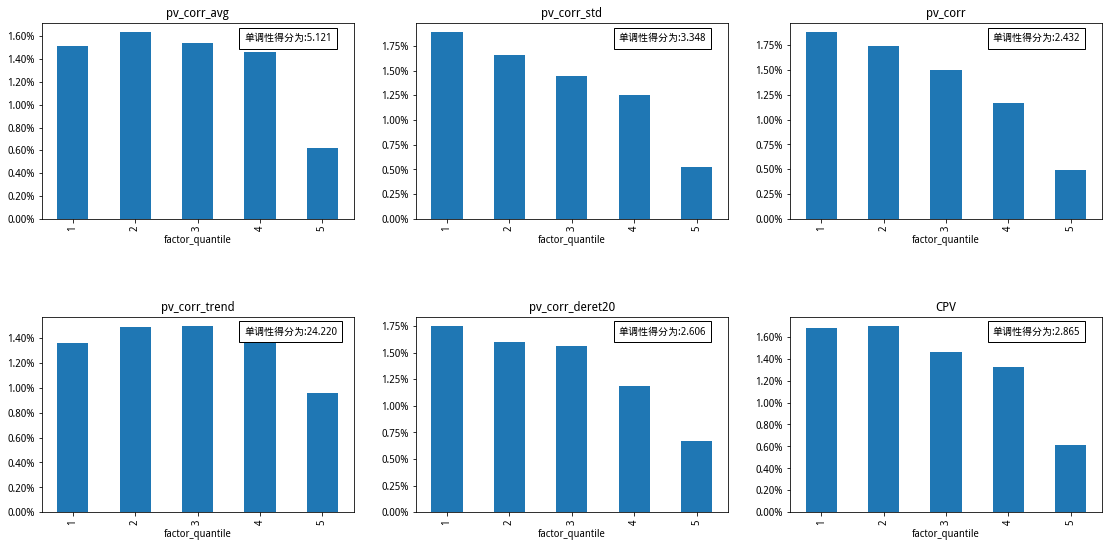

In [28]:
# ================================
# 因子分组平均收益柱状图
# 展示各分位平均收益 + 单调性得分
# ================================

# 创建多子图布局
fig, axis_array = plt.subplots(2, 3, figsize=(19, 9))

# 将二维子图展平为一维
axis_flat = [ax for sub in axis_array for ax in sub]

# 遍历每个因子的回测结果并绘图
for ax, (factor_name, res_obj) in zip(axis_flat, factor_analysis_results.items()):
    
    # 计算单调性得分
    monotonic_score = calc_mono_score(res_obj.group_daily_return)
    
    # 设置百分比格式
    ax.yaxis.set_major_formatter(
        mpl.ticker.FuncFormatter(lambda x, _: f"{x * 100:.2f}%")
    )
    
    # 显示单调性得分
    ax.text(
        0.65, 0.95,
        f"单调性得分为: {monotonic_score:.3f}",
        fontsize=10,
        bbox=dict(facecolor="white", alpha=1, pad=5),
        transform=ax.transAxes,
        verticalalignment="top"
    )
    
    # 绘制分组平均收益柱状图
    res_obj.group_daily_return.mean().plot.bar(
        ax=ax,
        title=factor_name,
        color="#1f77b4"
    )

# 调整子图间距
plt.subplots_adjust(hspace=0.5)

鉴于A股市场可运用的做空工具较为匮乏，本次研究将分析重点聚焦于多头组合。从上图能够观察到，第一组的收益表现相对更优，下面分别对第一组各年度的收益情况进行逐一分析：

In [59]:
# ================================
# 因子年度收益、IC、风险指标统计报告
# 包含年度收益率、IC信息表、风险指标表
# ================================

# 初始化空数据表
yearly_return_df = pd.DataFrame(columns=list(factor_analysis_results.keys()))
ic_statistics_df = pd.DataFrame(columns=list(factor_analysis_results.keys()))
risk_indicator_df = pd.DataFrame(columns=list(factor_analysis_results.keys()))

# 遍历所有因子回测结果，计算指标
for factor_name, result_obj in factor_analysis_results.items():
    
    # 按年度计算累计收益率（取年末值）
    yearly_return_df[factor_name] = result_obj.group_daily_return[1].groupby(
        pd.Grouper(level=0, freq='Y')
    ).apply(lambda x: ep.cum_returns(x).iloc[-1])
    
    # 计算IC信息表
    ic_statistics_df[factor_name] = get_information_table(
        perf.factor_information_coefficient(result_obj.cleaned_factor)
    ).iloc[:, 0]
    
    # 计算风险指标表
    risk_indicator_df[factor_name] = get_performance_table(
        result_obj.group_daily_return[[1]],
        periods='monthly'
    ).iloc[:, 0]

# 格式化年度索引
yearly_return_df.index = yearly_return_df.index.strftime('%Y')
yearly_return_df.index.names = ['年度']

# 渲染为带条件格式的表格
yearly_return_df.style.format('{:.2%}').bar(align='mid', color=['#5fba7d', '#d65f5f'])

,pv_corr_avg,pv_corr_std,pv_corr,pv_corr_trend,pv_corr_deret20,CPV
年度,,,,,,
2014,53.73%,68.62%,65.39%,55.99%,57.22%,59.41%
2015,19.73%,37.41%,34.34%,19.30%,41.24%,37.34%
2016,30.70%,35.17%,34.28%,28.65%,32.54%,33.58%
2017,-10.25%,-9.13%,-8.39%,-14.62%,-12.38%,-11.76%
2018,-22.41%,-22.85%,-21.41%,-29.72%,-24.58%,-25.94%
2019,30.71%,28.41%,31.11%,38.70%,30.40%,32.82%
2020,8.34%,12.23%,12.18%,5.41%,10.65%,8.14%
2021,24.46%,35.39%,32.15%,24.95%,29.57%,25.27%


In [62]:
# ================================
# 风险指标表可视化
# 百分比格式化 + 按行高亮最大值
# ================================

risk_indicator_df.style.format('{:.2%}').highlight_max(axis=1, color='#d65f5f')

,pv_corr_avg,pv_corr_std,pv_corr,pv_corr_trend,pv_corr_deret20,CPV
年化收益率,14.82%,20.41%,20.01%,13.11%,17.91%,17.08%
累计收益,195.24%,328.40%,317.44%,162.43%,263.53%,243.90%
波动率,29.51%,28.45%,29.27%,28.22%,30.25%,29.53%
夏普,61.59%,79.62%,77.07%,57.74%,69.47%,68.08%
最大回撤,-44.81%,-36.93%,-38.73%,-50.95%,-41.85%,-42.17%


In [55]:
# ================================
# 因子IC统计结果展示
# ================================

ic_statistics_df

,pv_corr_avg,pv_corr_std,pv_corr,pv_corr_trend,pv_corr_deret20,CPV
IC Mean,-0.046,-0.069,-0.076,-0.018,-0.050,-0.048
IC Std.,0.068,0.076,0.068,0.042,0.054,0.050
Risk-Adjusted IC,-0.680,-0.908,-1.113,-0.431,-0.918,-0.957
t-stat(IC),-6.589,-8.800,-10.794,-4.180,-8.905,-9.274
p-value(IC),0.000,0.000,0.000,0.000,0.000,0.000
IC Skew,-0.491,0.437,0.267,0.114,-0.169,0.405
IC Kurtosis,1.192,0.667,0.008,0.216,0.782,0.333


# 总结
本报告从技术分析中基础的价量关系出发，在测算个股每日高频价量相关系数的前提下，逐步挖掘其中蕴含的选股有效因子。

首先，研究构建了价量相关性的**平均数因子**与**波动性因子**。实证结果表明，两类因子均可视为对传统反转因子的优化修正。平均数因子体现为，个股月度行情能否实现反转需结合成交量信息判断，若存在成交量确认，月度行情反转效应更为显著；若无成交量配合，月度行情则更易表现出动量特征。波动性因子体现为，无论个股历史价格涨跌方向如何，只要日内价量关系保持稳定形态，次月上涨概率更高；价量关系在多种形态间频繁切换的个股，次月下跌可能性更大。

其次，研究发现个股价量相关性的变动趋势同样具备较好的选股效果，据此构建了**趋势因子**。回测结果显示，个股前期趋势因子数值越小，即价量相关系数随时间逐步降低，次月收益水平往往越高，该逻辑与平均数因子的选股思路相互印证。

最后，报告整合上述三个维度的信息，构建出最终的**价量相关性因子CPV**，该因子各项回测指标显著优于传统反转因子。在剔除市场常见风格与行业因素的影响后，纯净的CPV因子依然具备优异的选股效果。